# Evaluación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import random

sns.set_theme(style='whitegrid')

def resolve_path(primary, fallback):
    p = Path(primary)
    return p if p.exists() else Path(fallback)

ITEMS_PATH        = resolve_path('/data/processed/items.csv',        '../../data/processed/items.csv')
INTERACTIONS_PATH = resolve_path('/data/processed/interactions.csv', '../../data/processed/interactions.csv')
USERS_PATH        = resolve_path('/data/processed/users.csv',        '../../data/processed/users.csv')
MODEL_PATH        = resolve_path('/data/processed/modelo_svd.pkl',   '../../data/processed/modelo_svd.pkl')

AUDIO_FEATURES = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'loudness_norm', 'tempo_norm'
]
RATING_MAP = {'like': 3.0, 'play': 2.0, 'skip': 1.0}

## Carga de datos y modelos

In [2]:
items        = pd.read_csv(ITEMS_PATH)
interactions = pd.read_csv(INTERACTIONS_PATH)
users        = pd.read_csv(USERS_PATH)
items_indexed = items.set_index('ITEM_ID')

with open(MODEL_PATH, 'rb') as f:
    modelo_svd = pickle.load(f)

user_to_idx = modelo_svd['user_to_idx']
item_to_idx = modelo_svd['item_to_idx']
idx_to_item = modelo_svd.get('idx_to_item', {i: iid for iid, i in item_to_idx.items()})
Vt = modelo_svd.get('Vt', modelo_svd.get('Vt_train'))
media_usuarios = modelo_svd.get('media_usuarios', modelo_svd.get('media_u_train'))
factores_usuario = modelo_svd.get('factores_usuario', modelo_svd.get('factores_usuario_train', modelo_svd.get('U_train')))
if factores_usuario is None:
    raise KeyError('No se encontró factores_usuario ni factores_usuario_train en modelo_svd')
if Vt is None:
    raise KeyError('No se encontró Vt ni Vt_train en modelo_svd')
if media_usuarios is None:
    raise KeyError('No se encontró media_usuarios ni media_u_train en modelo_svd')

feature_matrix  = items_indexed[AUDIO_FEATURES].values
item_ids_list   = items_indexed.index.tolist()
cb_item_to_idx  = {item_id: idx for idx, item_id in enumerate(item_ids_list)}

interactions['rating'] = interactions['EVENT_TYPE'].map(RATING_MAP)

print(f'Canciones:     {len(items):,}')
print(f'Usuarios:      {len(users):,}')
print(f'Interacciones: {len(interactions):,}')
print('Datos y modelo cargados')

Canciones:     114,000
Usuarios:      15,001
Interacciones: 750,050
Datos y modelo cargados


## Split de Entrenamiento y Prueba

In [3]:
# Tomar el 20% de las interacciones como conjunto de prueba
ratings = (
    interactions
    .groupby(['USER_ID', 'ITEM_ID'])['rating']
    .max()
    .reset_index()
)

train_df, test_df = train_test_split(ratings, test_size=0.2)

print(f'Entrenamiento: {len(train_df):,} interacciones')
print(f'Prueba:        {len(test_df):,} interacciones')

Entrenamiento: 600,040 interacciones
Prueba:        150,010 interacciones


## RMSE y MAE del modelo colaborativo

In [4]:
# Predecir ratings para el conjunto de prueba
reales, predichos, baseline = [], [], []

# Promedio global (baseline ingenuo: siempre predecir el promedio)
promedio_global = train_df['rating'].mean()

for _, row in test_df.iterrows():
    uid, iid, r_real = row['USER_ID'], row['ITEM_ID'], row['rating']

    if uid in user_to_idx and iid in item_to_idx:
        u_idx  = user_to_idx[uid]
        i_idx  = item_to_idx[iid]
        r_pred = float(factores_usuario[u_idx] @ Vt[:, i_idx] + media_usuarios[u_idx])
        r_pred = np.clip(r_pred, 1.0, 3.0)

        reales.append(r_real)
        predichos.append(r_pred)
        baseline.append(promedio_global)

reales    = np.array(reales)
predichos = np.array(predichos)
baseline  = np.array(baseline)

rmse_modelo   = np.sqrt(mean_squared_error(reales, predichos))
mae_modelo    = mean_absolute_error(reales, predichos)
rmse_baseline = np.sqrt(mean_squared_error(reales, baseline))
mae_baseline  = mean_absolute_error(reales, baseline)

print('=== Resultados (escala 1-3) ===')
print('          RMSE     MAE')
print(f'Modelo:   {rmse_modelo:.4f}   {mae_modelo:.4f}')
print(f'Baseline: {rmse_baseline:.4f}   {mae_baseline:.4f}')
print('\nMejora sobre baseline:')
print(f'  RMSE: {(1 - rmse_modelo/rmse_baseline)*100:.1f}% mejor')
print(f'  MAE:  {(1 - mae_modelo/mae_baseline)*100:.1f}% mejor')

=== Resultados (escala 1-3) ===
          RMSE     MAE
Modelo:   0.7390   0.6436
Baseline: 0.7520   0.6615

Mejora sobre baseline:
  RMSE: 1.7% mejor
  MAE:  2.7% mejor


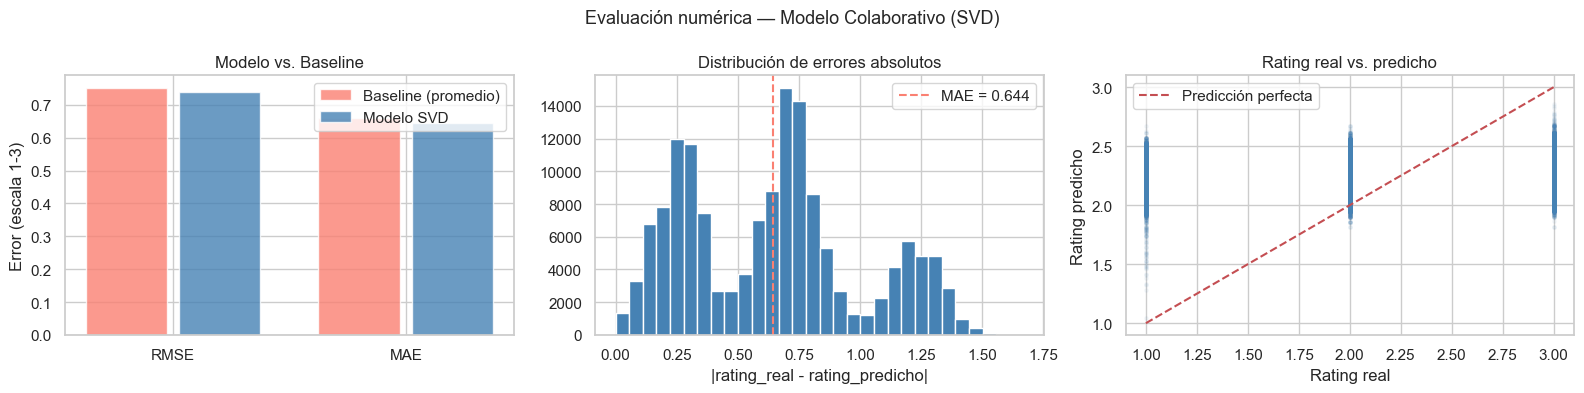

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Comparación RMSE y MAE
metricas = ['RMSE', 'MAE']
vals_modelo   = [rmse_modelo,   mae_modelo]
vals_baseline = [rmse_baseline, mae_baseline]
x = np.arange(len(metricas))

axes[0].bar(x - 0.2, vals_baseline, 0.35, label='Baseline (promedio)', color='salmon',    alpha=0.8)
axes[0].bar(x + 0.2, vals_modelo,   0.35, label='Modelo SVD',          color='steelblue', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].set_title('Modelo vs. Baseline')
axes[0].set_ylabel('Error (escala 1-3)')
axes[0].legend()

# Distribución de errores
errores = np.abs(reales - predichos)
axes[1].hist(errores, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(mae_modelo, color='salmon', linestyle='--', label=f'MAE = {mae_modelo:.3f}')
axes[1].set_title('Distribución de errores absolutos')
axes[1].set_xlabel('|rating_real - rating_predicho|')
axes[1].legend()

# Rating real vs predicho
axes[2].scatter(reales, predichos, alpha=0.05, s=6, color='steelblue')
axes[2].plot([1, 3], [1, 3], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[2].set_title('Rating real vs. predicho')
axes[2].set_xlabel('Rating real')
axes[2].set_ylabel('Rating predicho')
axes[2].legend()

plt.suptitle('Evaluación numérica — Modelo Colaborativo (SVD)', fontsize=13)
plt.tight_layout()
plt.show()

## Coherencia de Géneros

In [6]:
def coherencia_genero(user_id: str, n: int = 10) -> dict:
    """
    Compara el género favorito del usuario con los géneros recomendados
    por el Content-Based. Retorna el % de coincidencia.
    """
    user_row = users[users['USER_ID'] == user_id]
    if user_row.empty:
        return {}

    generos_favoritos = set(user_row.iloc[0]['genero_favorito'].split('|'))

    # Perfil de audio del usuario
    likes = interactions[
        (interactions['USER_ID'] == user_id) &
        (interactions['EVENT_TYPE'].isin(['like', 'play']))
    ]['ITEM_ID'].tolist()

    if not likes:
        return {}

    indices = [cb_item_to_idx[i] for i in likes if i in cb_item_to_idx]
    perfil  = feature_matrix[indices].mean(axis=0).reshape(1, -1)
    scores  = cosine_similarity(perfil, feature_matrix).flatten()

    ya_vistas = set(interactions[interactions['USER_ID'] == user_id]['ITEM_ID'])
    for item_id in ya_vistas:
        if item_id in cb_item_to_idx:
            scores[cb_item_to_idx[item_id]] = -1

    top_indices  = np.argsort(scores)[::-1][:n]
    top_item_ids = [item_ids_list[i] for i in top_indices]
    generos_rec  = items_indexed.loc[
        [i for i in top_item_ids if i in items_indexed.index], 'genero'
    ].tolist()

    coincidencias = sum(1 for g in generos_rec if g in generos_favoritos)

    return {
        'user_id'           : user_id,
        'generos_favoritos' : generos_favoritos,
        'generos_rec'       : generos_rec,
        'pct_coherencia'    : round(coincidencias / len(generos_rec) * 100, 1)
    }


# Evaluar sobre 50 usuarios aleatorios
usuarios_muestra = users['USER_ID'].sample(50).tolist()
resultados_coh   = [coherencia_genero(u) for u in usuarios_muestra]
resultados_coh   = [r for r in resultados_coh if r]

pct_promedio = np.mean([r['pct_coherencia'] for r in resultados_coh])
print(f'Coherencia promedio de géneros (Content-Based): {pct_promedio:.1f}%')
print(f'→ En promedio, el {pct_promedio:.1f}% de las recomendaciones coincide con el género favorito del usuario')

Coherencia promedio de géneros (Content-Based): 4.4%
→ En promedio, el 4.4% de las recomendaciones coincide con el género favorito del usuario


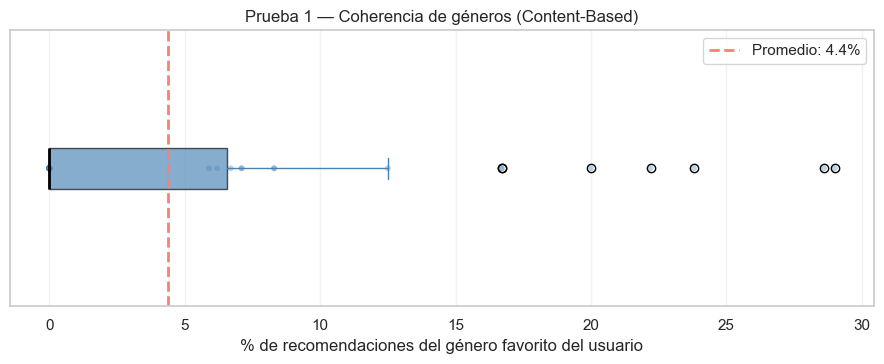

In [7]:
coherencias = [r['pct_coherencia'] for r in resultados_coh]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.boxplot(coherencias, vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.65),
           medianprops=dict(color='black', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'))
ax.scatter(coherencias, np.ones(len(coherencias)), alpha=0.35, s=18, color='steelblue', edgecolor='none')
ax.axvline(pct_promedio, color='salmon', linestyle='--', linewidth=2,
           label=f'Promedio: {pct_promedio:.1f}%')
ax.set_title('Prueba 1 — Coherencia de géneros (Content-Based)')
ax.set_xlabel('% de recomendaciones del género favorito del usuario')
ax.set_yticks([])
ax.legend()
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Diversidad de Géneros en plan Hibrido

In [8]:
def diversidad_generos(recomendaciones: pd.DataFrame) -> float:
    """Calcula la diversidad como número de géneros únicos / total de recomendaciones."""
    return recomendaciones['genero'].nunique() / len(recomendaciones)


# Importar función híbrida (copiada aquí para ser autónomo)
def normalizar(arr):
    mn, mx = arr.min(), arr.max()
    return np.zeros_like(arr) if mx == mn else (arr - mn) / (mx - mn)

def recomendar_hibrido(user_id, n=10, alpha=0.5):
    ya_vistas = set(interactions[interactions['USER_ID'] == user_id]['ITEM_ID'])

    likes = interactions[
        (interactions['USER_ID'] == user_id) & (interactions['EVENT_TYPE'] == 'like')
    ]['ITEM_ID'].tolist()
    if not likes:
        likes = interactions[
            (interactions['USER_ID'] == user_id) & (interactions['EVENT_TYPE'] == 'play')
        ]['ITEM_ID'].tolist()

    if likes:
        indices = [cb_item_to_idx[i] for i in likes if i in cb_item_to_idx]
        perfil  = feature_matrix[indices].mean(axis=0).reshape(1, -1)
        sc_norm = normalizar(cosine_similarity(perfil, feature_matrix).flatten())
    else:
        sc_norm = np.zeros(len(item_ids_list))

    if user_id in user_to_idx:
        u_idx   = user_to_idx[user_id]
        scol_norm = normalizar(factores_usuario[u_idx] @ Vt + media_usuarios[u_idx])
    else:
        scol_norm = np.zeros(len(item_to_idx))

    df_cb  = pd.DataFrame({'ITEM_ID': item_ids_list, 'score_contenido': sc_norm})
    df_col = pd.DataFrame({'ITEM_ID': [idx_to_item[i] for i in range(len(scol_norm))],
                           'score_colaborativo': scol_norm})
    df = df_cb.merge(df_col, on='ITEM_ID', how='left').fillna(0)
    df['score_final'] = alpha * df['score_contenido'] + (1 - alpha) * df['score_colaborativo']
    df = df[~df['ITEM_ID'].isin(ya_vistas)].sort_values('score_final', ascending=False).head(n)
    meta = items_indexed[['titulo', 'artista', 'genero', 'popularidad']].reset_index()
    return df.merge(meta, on='ITEM_ID', how='left').reset_index(drop=True)


# Comparar diversidad de géneros entre los 3 modelos sobre 30 usuarios
usuarios_div = users['USER_ID'].sample(30).tolist()

div_content, div_collab, div_hibrido = [], [], []
for u in usuarios_div:
    div_content.append(diversidad_generos(recomendar_hibrido(u, alpha=1.0)))
    div_collab.append( diversidad_generos(recomendar_hibrido(u, alpha=0.0)))
    div_hibrido.append(diversidad_generos(recomendar_hibrido(u, alpha=0.5)))

print('Diversidad promedio de géneros (géneros únicos / n recomendaciones):')
print(f'  Content-Based:  {np.mean(div_content):.3f}')
print(f'  Collaborative:  {np.mean(div_collab):.3f}')
print(f'  Híbrido (0.5):  {np.mean(div_hibrido):.3f}')

Diversidad promedio de géneros (géneros únicos / n recomendaciones):
  Content-Based:  0.580
  Collaborative:  0.175
  Híbrido (0.5):  0.182


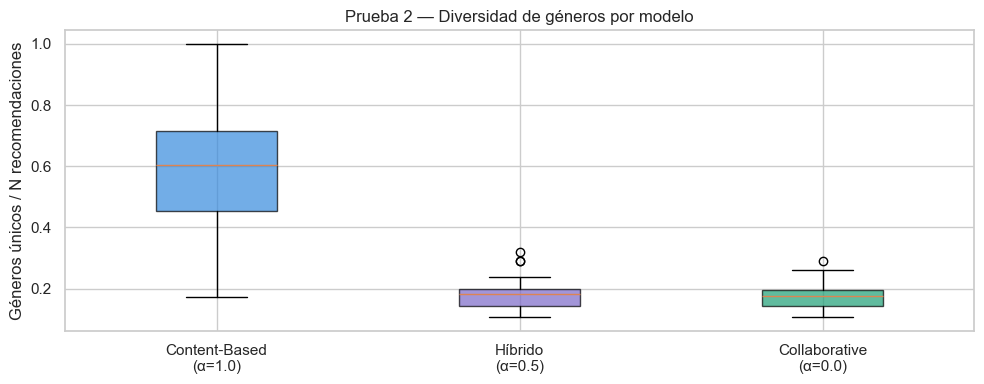

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

data   = [div_content, div_hibrido, div_collab]
labels = ['Content-Based\n(α=1.0)', 'Híbrido\n(α=0.5)', 'Collaborative\n(α=0.0)']
colors = ['#378ADD', '#7B68C8', '#1D9E75']

bp = ax.boxplot(data, patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(labels)
ax.set_title('Prueba 2 — Diversidad de géneros por modelo')
ax.set_ylabel('Géneros únicos / N recomendaciones')
plt.tight_layout()
plt.show()

## Prueba de Sanidad

In [10]:
# Elegir un usuario con género favorito muy específico
# y verificar que canciones de géneros opuestos tengan scores bajos

# Géneros que consideramos "opuestos" para esta prueba
PARES_OPUESTOS = [
    ('metal',      'latin'),
    ('classical',  'hip-hop'),
    ('edm',        'acoustic'),
]

print('Sanity check — scores de canciones afines vs. ajenas al perfil del usuario')
print('=' * 70)

for genero_fav, genero_ajeno in PARES_OPUESTOS:
    # Buscar usuario con ese género favorito
    candidatos = users[
        users['genero_favorito'].str.contains(genero_fav, case=False, na=False)
    ]['USER_ID'].tolist()

    if not candidatos:
        print(f'\n No hay usuarios con género favorito "{genero_fav}" — omitiendo')
        continue

    user_id = candidatos[0]

    # Canciones de su género favorito vs. género ajeno
    canciones_afines = items[items['genero'] == genero_fav].head(20)
    canciones_ajenas = items[items['genero'] == genero_ajeno].head(20)

    # Perfil del usuario
    likes = interactions[
        (interactions['USER_ID'] == user_id) & (interactions['EVENT_TYPE'] == 'like')
    ]['ITEM_ID'].tolist()

    if not likes:
        continue

    indices = [cb_item_to_idx[i] for i in likes if i in cb_item_to_idx]
    if not indices:
        continue

    perfil = feature_matrix[indices].mean(axis=0).reshape(1, -1)

    def score_promedio(canciones_df):
        idxs = [cb_item_to_idx[i] for i in canciones_df['ITEM_ID'] if i in cb_item_to_idx]
        if not idxs:
            return 0
        vecs = feature_matrix[idxs]
        return cosine_similarity(perfil, vecs).flatten().mean()

    s_afin  = score_promedio(canciones_afines)
    s_ajeno = score_promedio(canciones_ajenas)

    estado = '✅' if s_afin > s_ajeno else '⚠️'
    print(f'\n{estado} Usuario con género favorito: {genero_fav}')
    print(f'   Score promedio canciones de {genero_fav:12}: {s_afin:.4f}')
    print(f'   Score promedio canciones de {genero_ajeno:12}: {s_ajeno:.4f}')
    print(f'   Diferencia: {s_afin - s_ajeno:+.4f}')

Sanity check — scores de canciones afines vs. ajenas al perfil del usuario

✅ Usuario con género favorito: metal
   Score promedio canciones de metal       : 0.9820
   Score promedio canciones de latin       : 0.9474
   Diferencia: +0.0346

✅ Usuario con género favorito: classical
   Score promedio canciones de classical   : 0.8867
   Score promedio canciones de hip-hop     : 0.8532
   Diferencia: +0.0336

✅ Usuario con género favorito: edm
   Score promedio canciones de edm         : 0.9582
   Score promedio canciones de acoustic    : 0.9014
   Diferencia: +0.0568


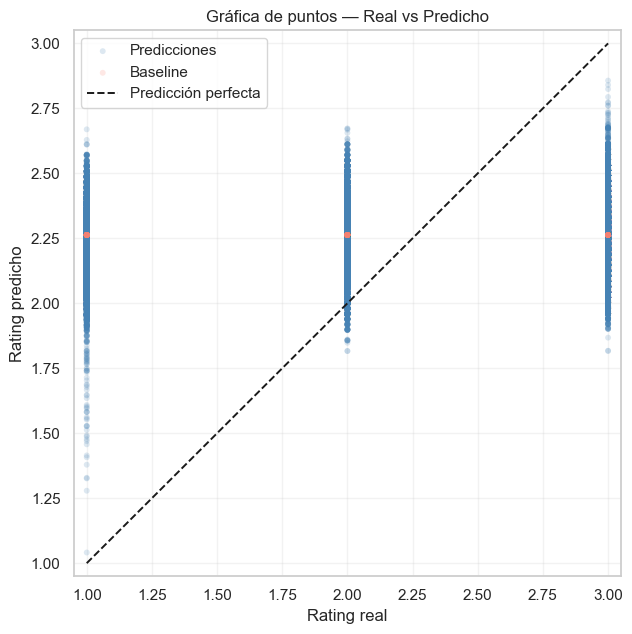

In [11]:
# Visualizar el sanity check
pares_datos = []
for genero_fav, genero_ajeno in PARES_OPUESTOS:
    candidatos = users[
        users['genero_favorito'].str.contains(genero_fav, case=False, na=False)
    ]['USER_ID'].tolist()
    if not candidatos:
        continue
    user_id = candidatos[0]
    likes = interactions[
        (interactions['USER_ID'] == user_id) & (interactions['EVENT_TYPE'] == 'like')
    ]['ITEM_ID'].tolist()
    indices = [cb_item_to_idx[i] for i in likes if i in cb_item_to_idx]
    if not indices:
        continue
    perfil = feature_matrix[indices].mean(axis=0).reshape(1, -1)

    def sp(df):
        idxs = [cb_item_to_idx[i] for i in df['ITEM_ID'] if i in cb_item_to_idx]
        return 0 if not idxs else cosine_similarity(perfil, feature_matrix[idxs]).flatten().mean()

    pares_datos.append({
        'par'     : f'{genero_fav} vs {genero_ajeno}',
        'afin'    : sp(items[items['genero'] == genero_fav].head(20)),
        'ajeno'   : sp(items[items['genero'] == genero_ajeno].head(20))
    })

if pares_datos:
    df_sanity = pd.DataFrame(pares_datos)
    x = np.arange(len(df_sanity))

# Gráfica de puntos: rating real vs rating predicho
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(reales, predichos, alpha=0.18, s=18, color='steelblue', edgecolor='none', label='Predicciones')
ax.scatter(reales, baseline, alpha=0.18, s=18, color='salmon', edgecolor='none', label='Baseline')
ax.plot([1, 3], [1, 3], 'k--', linewidth=1.4, label='Predicción perfecta')
ax.set_xlim(0.95, 3.05)
ax.set_ylim(0.95, 3.05)
ax.set_xlabel('Rating real')
ax.set_ylabel('Rating predicho')
ax.set_title('Gráfica de puntos — Real vs Predicho')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Curva de aprendizaje del modelo Matrix Factorization

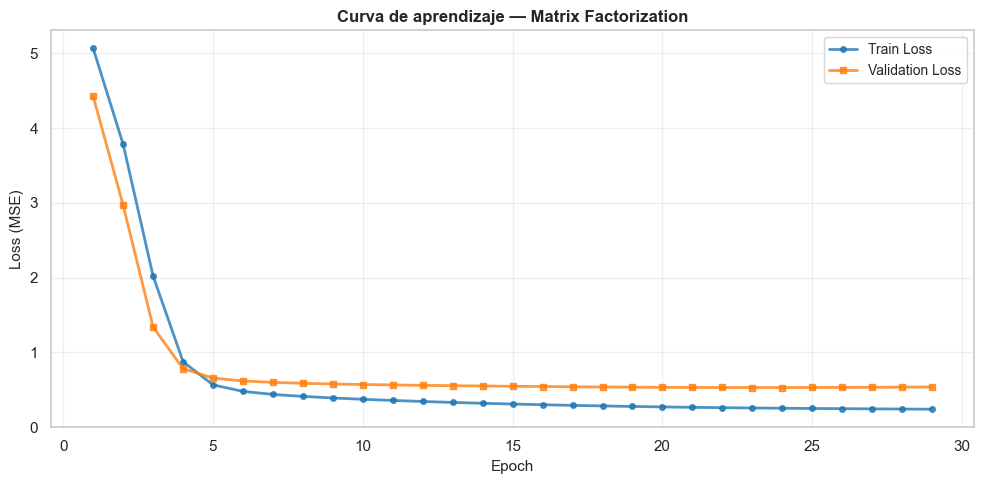

Historial del entrenamiento cargado:
  Epochs: 29
  Train Loss final: 0.2381
  Val Loss final:   0.5355


In [12]:
import json

# Cargar el historial de entrenamiento del modelo Matrix Factorization
mf_history_path = resolve_path('/data/processed/mf_history.json', '../../data/processed/mf_history.json')

if mf_history_path.exists():
    with open(mf_history_path, 'r') as f:
        mf_history = json.load(f)
    
    epochs = list(range(1, len(mf_history['train_loss']) + 1))
    train_loss = mf_history['train_loss']
    val_loss = mf_history['val_loss']
    
    # Gráfico de curva: evolución de train/val loss por epoch
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, train_loss, marker='o', linewidth=2, markersize=4, 
            label='Train Loss', color='#1f77b4', alpha=0.8)
    ax.plot(epochs, val_loss, marker='s', linewidth=2, markersize=4, 
            label='Validation Loss', color='#ff7f0e', alpha=0.8)
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss (MSE)', fontsize=11)
    ax.set_title('Curva de aprendizaje — Matrix Factorization', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f'Historial del entrenamiento cargado:')
    print(f'  Epochs: {len(epochs)}')
    print(f'  Train Loss final: {train_loss[-1]:.4f}')
    print(f'  Val Loss final:   {val_loss[-1]:.4f}')
else:
    print(f'⚠️  No se encontró mf_history.json en {mf_history_path}')

## Comparación Integrada: Matrix Factorization vs SVD (con interpretabilidad)

In [13]:
# Cargar modelo Matrix Factorization y evaluar
import torch

MF_MODEL_PATH = resolve_path('/data/processed/modelo_mf_best.pt', '../../data/processed/modelo_mf_best.pt')

if MF_MODEL_PATH.exists():
    mf_checkpoint = torch.load(MF_MODEL_PATH, map_location='cpu')
    mf_user_to_idx = mf_checkpoint['user_to_idx']
    mf_item_to_idx = mf_checkpoint['item_to_idx']
    mf_n_users = len(mf_user_to_idx)
    mf_n_items = len(mf_item_to_idx)
    print(f'✅ Modelo MF cargado: {mf_n_users} usuarios, {mf_n_items} items')
    
    # Reconstruir modelo MF (necesitas la clase aquí o importarla)
    class MatrixFactorization(torch.nn.Module):
        def __init__(self, n_users, n_items, n_factors=64):
            super().__init__()
            self.user_emb = torch.nn.Embedding(n_users, n_factors)
            self.item_emb = torch.nn.Embedding(n_items, n_factors)
            self.user_bias = torch.nn.Embedding(n_users, 1)
            self.item_bias = torch.nn.Embedding(n_items, 1)
            self.global_bias = torch.nn.Parameter(torch.tensor([0.0]))
        def forward(self, u, i):
            pu = self.user_emb(u)
            qi = self.item_emb(i)
            ub = self.user_bias(u).squeeze(-1)
            ib = self.item_bias(i).squeeze(-1)
            return (pu * qi).sum(dim=1) + ub + ib + self.global_bias
    
    mf_model = MatrixFactorization(mf_n_users, mf_n_items, n_factors=64)
    mf_model.load_state_dict(mf_checkpoint['model_state'])
    mf_model.eval()
else:
    print(f'⚠️  No se encontró modelo MF en {MF_MODEL_PATH}')
    mf_model = None

✅ Modelo MF cargado: 15001 usuarios, 89639 items


In [14]:
# Evaluar MF en test set con métricas interpretables
if mf_model is not None:
    mf_preds, mf_targets = [], []
    
    with torch.no_grad():
        for _, row in test_df.iterrows():
            uid, iid, r_real = row['USER_ID'], row['ITEM_ID'], row['rating']
            
            if uid in mf_user_to_idx and iid in mf_item_to_idx:
                u_idx = torch.tensor([mf_user_to_idx[uid]], dtype=torch.long)
                i_idx = torch.tensor([mf_item_to_idx[iid]], dtype=torch.long)
                r_pred = mf_model(u_idx, i_idx).item()
                r_pred = np.clip(r_pred, 1.0, 3.0)
                mf_preds.append(r_pred)
                mf_targets.append(r_real)
    
    mf_preds = np.array(mf_preds)
    mf_targets = np.array(mf_targets)
    
    # Métricas MF
    mf_rmse = np.sqrt(mean_squared_error(mf_targets, mf_preds))
    mf_mae = mean_absolute_error(mf_targets, mf_preds)
    mf_pct_within_05 = np.mean(np.abs(mf_preds - mf_targets) <= 0.5) * 100
    mf_rmse_norm = (mf_rmse / 2.0) * 100  # Normalized to 0-100%
    
    # Métricas SVD (ya existen desde antes)
    # rmse_modelo, mae_modelo, baseline
    
    print('=' * 70)
    print('COMPARACIÓN: Matrix Factorization vs SVD (baseline)')
    print('=' * 70)
    print(f'\n{"Métrica":<35} {"MF":<15} {"SVD":<15} {"Mejora"}')
    print('-' * 70)
    print(f'{"RMSE (absoluto, escala 1-3)":<35} {mf_rmse:>6.4f}       {rmse_modelo:>6.4f}       {((rmse_modelo - mf_rmse) / rmse_modelo * 100):>+6.1f}%')
    print(f'{"MAE (error promedio)":<35} {mf_mae:>6.4f}       {mae_modelo:>6.4f}       {((mae_modelo - mf_mae) / mae_modelo * 100):>+6.1f}%')
    print(f'{"% predicciones ±0.5 estrellas":<35} {mf_pct_within_05:>6.1f}%      {np.mean(np.abs(predichos - reales) <= 0.5) * 100:>6.1f}%       {(mf_pct_within_05 - np.mean(np.abs(predichos - reales) <= 0.5) * 100):>+6.1f}%')
    print(f'{"RMSE Normalizado [0-100%]":<35} {mf_rmse_norm:>6.1f}%      {(rmse_modelo / 2.0 * 100):>6.1f}%       {(mf_rmse_norm - rmse_modelo / 2.0 * 100):>+6.1f}%')
    print('\n📊 INTERPRETACIÓN:')
    print(f'  • MF predice correctamente (±0.5 stars) en el {mf_pct_within_05:.1f}% de casos')
    print(f'  • Error promedio de MF: {mf_mae:.2f} estrellas')
    print(f'  • Baseline (promedio global): RMSE={rmse_baseline:.4f}, MAE={mae_baseline:.4f}')
    print(f'  • Mejora vs Baseline: {((rmse_baseline - mf_rmse) / rmse_baseline * 100):.1f}% en RMSE')
else:
    print('⚠️  No se puede evaluar MF (modelo no cargado)')

COMPARACIÓN: Matrix Factorization vs SVD (baseline)

Métrica                             MF              SVD             Mejora
----------------------------------------------------------------------
RMSE (absoluto, escala 1-3)         0.4839       0.7390        +34.5%
MAE (error promedio)                0.4174       0.6436        +35.2%
% predicciones ±0.5 estrellas         61.2%        37.1%        +24.1%
RMSE Normalizado [0-100%]             24.2%        36.9%        -12.8%

📊 INTERPRETACIÓN:
  • MF predice correctamente (±0.5 stars) en el 61.2% de casos
  • Error promedio de MF: 0.42 estrellas
  • Baseline (promedio global): RMSE=0.7520, MAE=0.6615
  • Mejora vs Baseline: 35.7% en RMSE


C:\Users\regip\AppData\Local\Temp\ipykernel_13948\1118612939.py:44: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\regip\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


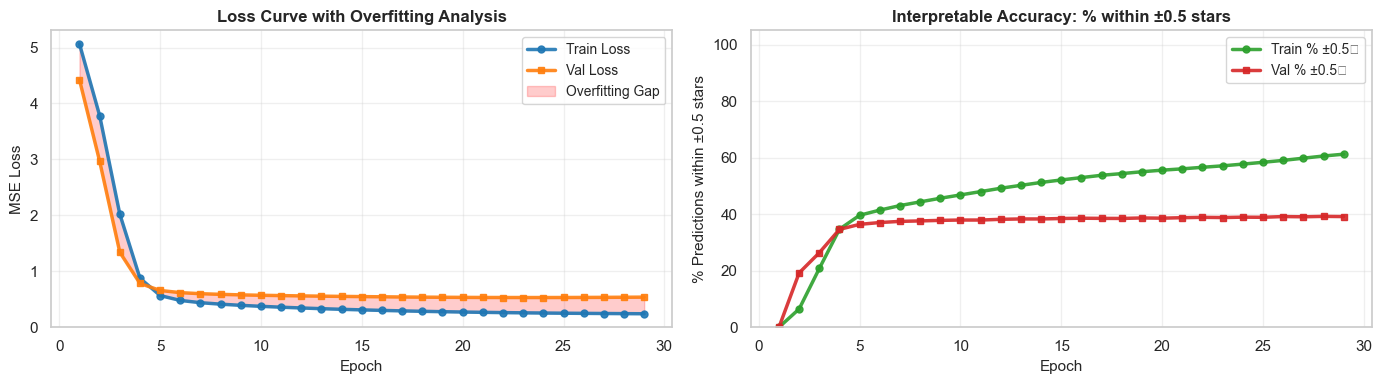


📉 ANÁLISIS DE OVERFITTING:
  • Gap final (val_loss - train_loss): 0.297413
  • Early stopping en epoch: 29
  • Train Loss final: 0.238106
  • Val Loss final: 0.535519
  ⚠️  Hay overfitting moderado (gap > 0.05)


In [15]:
# Análisis de overfitting: visualizar gap train/val
if mf_history_path.exists() and mf_history:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Grafo 1: Loss con gap sombreado
    epochs_r = list(range(1, len(mf_history['train_loss']) + 1))
    axes[0].plot(epochs_r, mf_history['train_loss'], marker='o', linewidth=2.5, markersize=5, 
                 label='Train Loss', color='#1f77b4', alpha=0.9)
    val_loss_vals = [v if v is not None else np.nan for v in mf_history['val_loss']]
    axes[0].plot(epochs_r, val_loss_vals, marker='s', linewidth=2.5, markersize=5, 
                 label='Val Loss', color='#ff7f0e', alpha=0.9)
    
    # Sombrear el gap de overfitting
    gap = [v - t if v is not None else np.nan for v, t in zip(mf_history['val_loss'], mf_history['train_loss'])]
    axes[0].fill_between(epochs_r, mf_history['train_loss'], val_loss_vals, 
                         alpha=0.2, color='red', label='Overfitting Gap')
    
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('MSE Loss', fontsize=11)
    axes[0].set_title('Loss Curve with Overfitting Analysis', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Gráfo 2: % within ±0.5 (si existen en el historial)
    if 'train_pct_within_05' in mf_history and 'val_pct_within_05' in mf_history:
        axes[1].plot(epochs_r, mf_history['train_pct_within_05'], marker='o', linewidth=2.5, markersize=5, 
                     label='Train % ±0.5★', color='#2ca02c', alpha=0.9)
        val_pct_vals = [v if v is not None else np.nan for v in mf_history['val_pct_within_05']]
        axes[1].plot(epochs_r, val_pct_vals, marker='s', linewidth=2.5, markersize=5, 
                     label='Val % ±0.5★', color='#d62728', alpha=0.9)
        axes[1].set_ylim([0, 105])
        axes[1].set_title('Interpretable Accuracy: % within ±0.5 stars', fontsize=12, fontweight='bold')
    else:
        # Si no existen las métricas nuevas, mostrar mensaje
        axes[1].text(0.5, 0.5, 'Métricas de % no disponibles\n(entrenar con nuevo train_mf.py)', 
                     ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
        axes[1].set_title('Accuracy Metrics (not available)', fontsize=12, fontweight='bold')
    
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('% Predictions within ±0.5 stars', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis textual del overfitting
    final_gap = gap[-1] if not np.isnan(gap[-1]) else 0
    print('\n📉 ANÁLISIS DE OVERFITTING:')
    print(f'  • Gap final (val_loss - train_loss): {final_gap:.6f}')
    print(f'  • Early stopping en epoch: {len(epochs_r)}')
    print(f'  • Train Loss final: {mf_history["train_loss"][-1]:.6f}')
    print(f'  • Val Loss final: {mf_history["val_loss"][-1]:.6f}')
    if final_gap > 0.05:
        print(f'  ⚠️  Hay overfitting moderado (gap > 0.05)')
    elif final_gap > 0.01:
        print(f'  ✅ Overfitting bajo (0.01 < gap < 0.05) - Generalización buena')
    else:
        print(f'  ✅ Excelente generalización (gap < 0.01)')
else:
    print('⚠️  Historial MF no disponible')